In [1]:
from pathlib import Path

FIGS_ROOT = Path("figs")
PLOT_OUTPUT_DIR = FIGS_ROOT / "prior_analysis"
CONFIG_IDS = ["config_018", "config_013", "config_012", "config_014", "config_015", "config_017"]
PRIORS = ["uniform", "normal", "exponential", "grid"]
LOAD_RAW = True
RAW_MAX_POINTS_PER_CONFIG = 256

# Prior Analysis

This notebook compares the clean 1D-6D `toy_example_nD_tidy.py` sweep from the perspective of **prior choice**.

It keeps the same summary artifacts used in `dimensionality_analysis.ipynb`, but flips the presentation:
- priors are the main comparison axis,
- dimensions become the sweep context,
- and dimension-specific panels make it easy to see where each prior helps or hurts.

Notes:
- The default sweep is `config_018, 013, 012, 014, 015, 017`, which resolve to dimensions `1, 2, 3, 4, 5, 6`.
- The fast path uses the saved summary JSON artifacts only.
- The optional raw deep-dive samples compact-store arrays with a lower cap so all six dimensions remain practical.

In [2]:
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

from src.dimensionality_analysis import load_dimensionality_summary, load_raw_compact_store

warnings.simplefilter("default")
pd.options.display.max_columns = 80
pd.options.display.float_format = "{:.3f}".format

PRIOR_COLORS = {
    "uniform": "#1f77b4",
    "normal": "#d17a22",
    "exponential": "#2a9d4b",
    "grid": "#7b61ff",
}
PRIOR_MARKERS = {
    "uniform": "o",
    "normal": "s",
    "exponential": "^",
    "grid": "D",
}
PRIOR_LABELS = {prior: prior.title() for prior in PRIOR_COLORS}
DIMENSION_MARKER_SEQUENCE = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]


def normalized_config_ids(config_ids):
    return [config_id if str(config_id).startswith("config_") else f"config_{config_id}" for config_id in config_ids]


def active_priors(dataframe):
    if dataframe is None or getattr(dataframe, "empty", True) or "prior" not in dataframe.columns:
        return list(PRIORS)
    present_priors = set(dataframe["prior"].dropna().astype(str))
    return [prior for prior in PRIORS if prior in present_priors]


def ordered_dimensions(dataframe):
    if dataframe is None or getattr(dataframe, "empty", True) or "dimension" not in dataframe.columns:
        return []
    return sorted(int(value) for value in pd.Series(dataframe["dimension"]).dropna().unique())


def build_dimension_style_maps(dimensions):
    dimensions = list(dimensions)
    color_positions = np.linspace(0.1, 0.9, num=max(len(dimensions), 1))
    colors = {dim: plt.cm.viridis(position) for dim, position in zip(dimensions, color_positions)}
    markers = {
        dim: DIMENSION_MARKER_SEQUENCE[index % len(DIMENSION_MARKER_SEQUENCE)]
        for index, dim in enumerate(dimensions)
    }
    return colors, markers


def build_dimension_legend_handles(dimensions):
    colors, markers = build_dimension_style_maps(dimensions)
    return [
        Line2D(
            [0],
            [0],
            color=colors[dimension],
            marker=markers[dimension],
            linewidth=2,
            label=f"{dimension}D",
        )
        for dimension in dimensions
    ]


def build_prior_legend_handles(priors):
    return [
        Line2D(
            [0],
            [0],
            color=PRIOR_COLORS.get(prior, "gray"),
            marker=PRIOR_MARKERS.get(prior, "o"),
            linewidth=2,
            label=PRIOR_LABELS.get(prior, prior),
        )
        for prior in priors
    ]


def add_shared_colorbar(fig, axes, mappable, label, *, right=0.88, pad=0.02, top=0.9, bottom=0.14, left=0.08, wspace=0.28, hspace=0.25):
    axes_list = np.atleast_1d(axes).ravel().tolist()
    fig.subplots_adjust(left=left, right=right, bottom=bottom, top=top, wspace=wspace, hspace=hspace)
    colorbar = fig.colorbar(mappable, ax=axes_list, fraction=0.035, pad=pad)
    colorbar.set_label(label)
    return colorbar


def save_figure(fig, filename, *, dpi=200):
    PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output_path = PLOT_OUTPUT_DIR / f"{filename}.pdf"
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    return output_path


def build_compact_metric_table(runs_df):
    columns = [
        "config_id",
        "dimension",
        "prior",
        "pooled_rmse_log_r10",
        "median_rmse_log_r10",
        "worst_rmse_log_r10",
        "median_ess_fraction",
        "median_swd",
        "coverage_68",
        "coverage_gap_68",
        "coverage_95",
        "coverage_gap_95",
        "mean_interval_width_68",
        "mean_interval_width_95",
    ]
    return runs_df[columns].sort_values(["dimension", "prior"]).reset_index(drop=True)


def build_prior_summary(runs_df):
    if runs_df.empty:
        return pd.DataFrame()
    summary = (
        runs_df.groupby("prior")
        .agg(
            mean_pooled_rmse=("pooled_rmse_log_r10", "mean"),
            median_pooled_rmse=("pooled_rmse_log_r10", "median"),
            mean_median_rmse=("median_rmse_log_r10", "mean"),
            mean_worst_rmse=("worst_rmse_log_r10", "mean"),
            mean_median_ess_fraction=("median_ess_fraction", "mean"),
            median_median_ess_fraction=("median_ess_fraction", "median"),
            mean_median_swd=("median_swd", "mean"),
            mean_coverage_68=("coverage_68", "mean"),
            mean_coverage_gap_68=("coverage_gap_68", "mean"),
            mean_coverage_95=("coverage_95", "mean"),
            mean_coverage_gap_95=("coverage_gap_95", "mean"),
            mean_interval_width_68=("mean_interval_width_68", "mean"),
            mean_interval_width_95=("mean_interval_width_95", "mean"),
        )
        .reindex(active_priors(runs_df))
        .reset_index()
    )
    return summary


def build_dimension_winner_table(runs_df):
    if runs_df.empty:
        return pd.DataFrame()
    metric_rules = [
        ("best_pooled_rmse", "pooled_rmse_log_r10", True),
        ("best_median_rmse", "median_rmse_log_r10", True),
        ("best_median_ess_fraction", "median_ess_fraction", False),
        ("best_median_swd", "median_swd", True),
        ("best_coverage_gap_68", "coverage_gap_68", True),
        ("best_coverage_gap_95", "coverage_gap_95", True),
    ]
    rows = []
    for dimension, subset in runs_df.groupby("dimension"):
        row = {"dimension": int(dimension)}
        for label, metric, ascending in metric_rules:
            ranked = subset.sort_values([metric, "prior"], ascending=[ascending, True]).reset_index(drop=True)
            best = ranked.iloc[0]
            row[label] = f"{best['prior']} ({best[metric]:.3f})"
        rows.append(row)
    return pd.DataFrame(rows).sort_values("dimension").reset_index(drop=True)


def build_prior_win_count_table(runs_df):
    if runs_df.empty:
        return pd.DataFrame()
    metric_rules = {
        "pooled_rmse_win": ("pooled_rmse_log_r10", True),
        "median_rmse_win": ("median_rmse_log_r10", True),
        "median_ess_fraction_win": ("median_ess_fraction", False),
        "median_swd_win": ("median_swd", True),
        "coverage_gap_68_win": ("coverage_gap_68", True),
        "coverage_gap_95_win": ("coverage_gap_95", True),
    }
    wins = []
    for dimension, subset in runs_df.groupby("dimension"):
        for win_label, (metric, ascending) in metric_rules.items():
            ranked = subset.sort_values([metric, "prior"], ascending=[ascending, True]).reset_index(drop=True)
            wins.append({
                "dimension": int(dimension),
                "metric": win_label,
                "prior": str(ranked.loc[0, "prior"]),
            })
    wins_df = pd.DataFrame(wins)
    summary = wins_df.pivot_table(index="prior", columns="metric", values="dimension", aggfunc="count", fill_value=0)
    summary = summary.reindex(active_priors(runs_df)).fillna(0).astype(int)
    summary["total_wins"] = summary.sum(axis=1)
    return summary.reset_index()


def build_delta_vs_uniform_table(runs_df):
    if runs_df.empty or "uniform" not in set(runs_df["prior"].astype(str)):
        return pd.DataFrame()
    baseline = runs_df.loc[runs_df["prior"].astype(str) == "uniform"].set_index("dimension")
    rows = []
    for prior in active_priors(runs_df):
        if prior == "uniform":
            continue
        subset = runs_df.loc[runs_df["prior"].astype(str) == prior].set_index("dimension")
        common_dimensions = baseline.index.intersection(subset.index)
        if common_dimensions.empty:
            continue
        base = baseline.loc[common_dimensions]
        comp = subset.loc[common_dimensions]
        rows.append(
            {
                "prior": prior,
                "delta_pooled_rmse": float((comp["pooled_rmse_log_r10"] - base["pooled_rmse_log_r10"]).mean()),
                "delta_median_rmse": float((comp["median_rmse_log_r10"] - base["median_rmse_log_r10"]).mean()),
                "delta_median_ess_fraction": float((comp["median_ess_fraction"] - base["median_ess_fraction"]).mean()),
                "delta_median_swd": float((comp["median_swd"] - base["median_swd"]).mean()),
                "delta_coverage_gap_68": float((comp["coverage_gap_68"] - base["coverage_gap_68"]).mean()),
                "delta_mean_interval_width_68": float((comp["mean_interval_width_68"] - base["mean_interval_width_68"]).mean()),
            }
        )
    return pd.DataFrame(rows).sort_values("delta_pooled_rmse").reset_index(drop=True)


def build_correlation_summary(pairs_df):
    if pairs_df.empty:
        return pd.DataFrame()
    rows = []
    for (dimension, prior), subset in pairs_df.groupby(["dimension", "prior"]):
        rows.append(
            {
                "dimension": int(dimension),
                "prior": str(prior),
                "spearman_rmse_vs_distance": subset["distance"].corr(subset["rmse_log_r10"], method="spearman"),
                "spearman_swd_vs_distance": subset["distance"].corr(subset["swd"], method="spearman"),
                "spearman_ess_fraction_vs_distance": subset["distance"].corr(subset["ess_fraction"], method="spearman"),
            }
        )
    return pd.DataFrame(rows).sort_values(["dimension", "prior"]).reset_index(drop=True)


def build_prior_observation_markdown(prior_summary_df, prior_win_count_df, delta_vs_uniform_df):
    if prior_summary_df.empty:
        return Markdown("No prior summary was loaded.")

    best_rmse = prior_summary_df.loc[prior_summary_df["mean_pooled_rmse"].idxmin()]
    best_ess = prior_summary_df.loc[prior_summary_df["mean_median_ess_fraction"].idxmax()]
    best_cal = prior_summary_df.loc[prior_summary_df["mean_coverage_gap_68"].idxmin()]

    lines = ["### Prior-focused interpretation"]
    lines.append(
        f"- **{PRIOR_LABELS.get(best_rmse['prior'], best_rmse['prior'])}** has the lowest mean pooled RMSE across the 1D-6D sweep (**{best_rmse['mean_pooled_rmse']:.3f}**)."
    )
    lines.append(
        f"- **{PRIOR_LABELS.get(best_ess['prior'], best_ess['prior'])}** has the largest average median ESS fraction (**{best_ess['mean_median_ess_fraction']:.3f}**), so it tends to preserve the strongest reweighting support."
    )
    lines.append(
        f"- **{PRIOR_LABELS.get(best_cal['prior'], best_cal['prior'])}** is closest to nominal 68% coverage on average, with a mean absolute coverage gap of **{best_cal['mean_coverage_gap_68']:.3f}**."
    )

    if not prior_win_count_df.empty:
        win_leader = prior_win_count_df.sort_values(["total_wins", "prior"], ascending=[False, True]).iloc[0]
        lines.append(
            f"- In the dimension-by-dimension win table, **{PRIOR_LABELS.get(win_leader['prior'], win_leader['prior'])}** collects the most metric wins (**{int(win_leader['total_wins'])}** total)."
        )

    if delta_vs_uniform_df is not None and not delta_vs_uniform_df.empty:
        strongest_rmse_delta = delta_vs_uniform_df.sort_values(["delta_pooled_rmse", "prior"]).iloc[0]
        if strongest_rmse_delta["delta_pooled_rmse"] < 0:
            lines.append(
                f"- Relative to the uniform baseline, **{PRIOR_LABELS.get(strongest_rmse_delta['prior'], strongest_rmse_delta['prior'])}** yields the strongest mean pooled-RMSE improvement (**{strongest_rmse_delta['delta_pooled_rmse']:.3f}**)."
            )

    return Markdown("\n".join(lines))


def plot_metric_vs_prior(ax, data, metric, title, ylabel, *, logy=False, nominal=None):
    priors = active_priors(data)
    dimensions = ordered_dimensions(data)
    x_positions = np.arange(len(priors))
    colors, markers = build_dimension_style_maps(dimensions)
    for dimension in dimensions:
        subset = data.loc[data["dimension"] == dimension].copy()
        if subset.empty:
            continue
        subset["prior"] = subset["prior"].astype(str)
        subset = subset.set_index("prior").reindex(priors).reset_index()
        ax.plot(
            x_positions,
            subset[metric],
            color=colors[dimension],
            marker=markers[dimension],
            linewidth=2,
            markersize=7,
            label=f"{dimension}D",
        )
    if nominal is not None:
        ax.axhline(nominal, color="black", linestyle="--", linewidth=1.4, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Prior")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([PRIOR_LABELS.get(prior, prior) for prior in priors], rotation=20)
    ax.grid(alpha=0.3)
    if logy:
        ax.set_yscale("log")


def plot_metric_by_dimension_panels(data, metric, title_prefix, ylabel, *, nominal=None, logy=False, figsize=(16, 8), sharey=True):
    dimensions = ordered_dimensions(data)
    priors = active_priors(data)
    fig, axes = plt.subplots(2, 3, figsize=figsize, sharex=True, sharey=sharey, squeeze=False)
    axes = axes.ravel()
    x_positions = np.arange(len(priors))
    for ax, dimension in zip(axes, dimensions):
        subset = data.loc[data["dimension"] == dimension].copy()
        subset["prior"] = subset["prior"].astype(str)
        subset = subset.set_index("prior").reindex(priors).reset_index()
        values = subset[metric].to_numpy(dtype=float)
        ax.plot(x_positions, values, color="0.35", linewidth=1.6, alpha=0.85)
        ax.scatter(
            x_positions,
            values,
            s=85,
            c=[PRIOR_COLORS.get(prior, "gray") for prior in priors],
            marker="o",
            edgecolor="black",
            linewidth=0.6,
            zorder=3,
        )
        if nominal is not None:
            ax.axhline(nominal, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
        ax.set_title(f"{dimension}D")
        ax.set_xticks(x_positions)
        ax.set_xticklabels([PRIOR_LABELS.get(prior, prior) for prior in priors], rotation=20)
        ax.grid(alpha=0.25)
        if logy:
            ax.set_yscale("log")
    for ax in axes[len(dimensions):]:
        ax.set_axis_off()
    for ax in axes[::3]:
        ax.set_ylabel(ylabel)
    for ax in axes[-3:]:
        ax.set_xlabel("Prior")
    legend_handles = build_prior_legend_handles(priors)
    if legend_handles:
        fig.legend(handles=legend_handles, loc="upper center", ncol=min(len(legend_handles), 4), frameon=False)
    fig.suptitle(title_prefix, y=1.02)
    fig.tight_layout()
    return fig


def plot_prior_facet_metric_grid(pairs_df):
    priors = active_priors(pairs_df)
    metrics = [
        ("rmse_log_r10", "RMSE log10 ratio"),
        ("swd", "Sliced Wasserstein distance"),
        ("ess_fraction", "ESS fraction"),
    ]
    fig, axes = plt.subplots(len(metrics), len(priors), figsize=(4.4 * len(priors), 3.5 * len(metrics)), sharex="col", squeeze=False)
    scatter = None
    for column, prior in enumerate(priors):
        prior_subset = pairs_df.loc[pairs_df["prior"].astype(str) == prior]
        for row, (metric, ylabel) in enumerate(metrics):
            ax = axes[row, column]
            scatter = ax.scatter(
                prior_subset["distance"],
                prior_subset[metric],
                c=prior_subset["dimension"],
                cmap="viridis",
                s=34,
                alpha=0.72,
                edgecolor="none",
            )
            if row == 0:
                ax.set_title(PRIOR_LABELS.get(prior, prior))
            if column == 0:
                ax.set_ylabel(ylabel)
            if row == len(metrics) - 1:
                ax.set_xlabel("Parameter-pair distance")
            ax.grid(alpha=0.22)
    if scatter is not None:
        add_shared_colorbar(fig, axes, scatter, "Dimension", right=0.9, pad=0.02, top=0.92, bottom=0.12, left=0.06, wspace=0.2, hspace=0.28)
    else:
        fig.subplots_adjust(left=0.06, right=0.98, bottom=0.12, top=0.92, wspace=0.2, hspace=0.28)
    return fig


def plot_curve_by_dimension(curves_df, metric, ylabel, title_prefix, *, figsize=(16, 8)):
    dimensions = ordered_dimensions(curves_df)
    priors = active_priors(curves_df)
    fig, axes = plt.subplots(2, 3, figsize=figsize, sharex=True, squeeze=False)
    axes = axes.ravel()
    for ax, dimension in zip(axes, dimensions):
        subset = curves_df.loc[curves_df["dimension"] == dimension]
        for prior in priors:
            curve = subset.loc[subset["prior"].astype(str) == prior].sort_values("x_value")
            if curve.empty:
                continue
            ax.plot(
                curve["x_value"],
                curve[metric],
                color=PRIOR_COLORS.get(prior),
                marker=PRIOR_MARKERS.get(prior, "o"),
                linewidth=2,
                markersize=4,
                label=PRIOR_LABELS.get(prior, prior),
            )
        ax.set_title(f"{dimension}D")
        ax.set_xlabel("True value")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25)
    for ax in axes[len(dimensions):]:
        ax.set_axis_off()
    legend_handles = build_prior_legend_handles(priors)
    if legend_handles:
        fig.legend(handles=legend_handles, loc="upper center", ncol=min(len(legend_handles), 4), frameon=False)
    fig.suptitle(title_prefix, y=1.02)
    fig.tight_layout()
    return fig


def plot_curve_heatmaps_by_dimension(curves_df, metric, colorbar_label, cmap):
    dimensions = ordered_dimensions(curves_df)
    priors = active_priors(curves_df)
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), squeeze=False)
    axes = axes.ravel()
    images = []
    for ax, dimension in zip(axes, dimensions):
        subset = curves_df.loc[curves_df["dimension"] == dimension]
        heatmap = subset.pivot_table(index="prior", columns="x_value", values=metric, aggfunc="mean")
        heatmap = heatmap.reindex(priors)
        masked_values = np.ma.masked_invalid(heatmap.to_numpy(dtype=float))
        image = ax.imshow(masked_values, aspect="auto", origin="lower", cmap=cmap)
        images.append(image)
        ax.set_title(f"{dimension}D")
        ax.set_xlabel("True value")
        ax.set_ylabel("Prior")
        x_positions = np.linspace(0, len(heatmap.columns) - 1, num=min(5, len(heatmap.columns)), dtype=int)
        ax.set_xticks(x_positions)
        ax.set_xticklabels([f"{heatmap.columns[pos]:.1f}" for pos in x_positions])
        ax.set_yticks(np.arange(len(priors)))
        ax.set_yticklabels([PRIOR_LABELS.get(prior, prior) for prior in priors])
    for ax in axes[len(dimensions):]:
        ax.set_axis_off()
    if images:
        add_shared_colorbar(fig, axes, images[0], colorbar_label, right=0.9, pad=0.03, top=0.9, bottom=0.12, left=0.08, wspace=0.28, hspace=0.32)
    else:
        fig.subplots_adjust(left=0.08, right=0.98, bottom=0.12, top=0.9, wspace=0.28, hspace=0.32)
    return fig


def plot_raw_boxplots_by_dimension(raw_df, value_col, ylabel, title_prefix, *, add_zero_line=False, figsize=(16, 8)):
    dimensions = ordered_dimensions(raw_df)
    priors = active_priors(raw_df)
    fig, axes = plt.subplots(2, 3, figsize=figsize, sharex=True, squeeze=False)
    axes = axes.ravel()
    for ax, dimension in zip(axes, dimensions):
        subset = raw_df.loc[raw_df["dimension"] == dimension]
        box_data = [
            subset.loc[subset["prior"].astype(str) == prior, value_col].to_numpy(dtype=float)
            for prior in priors
        ]
        boxplot = ax.boxplot(
            box_data,
            labels=[PRIOR_LABELS.get(prior, prior) for prior in priors],
            patch_artist=True,
            showfliers=False,
        )
        for patch, prior in zip(boxplot["boxes"], priors):
            patch.set_facecolor(PRIOR_COLORS.get(prior, "gray"))
            patch.set_alpha(0.6)
        for median in boxplot["medians"]:
            median.set_color("black")
            median.set_linewidth(1.4)
        if add_zero_line:
            ax.axhline(0.0, color="black", linestyle="--", linewidth=1.1, alpha=0.8)
        ax.set_title(f"{dimension}D")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.22)
        for label in ax.get_xticklabels():
            label.set_rotation(20)
    for ax in axes[len(dimensions):]:
        ax.set_axis_off()
    fig.suptitle(title_prefix, y=1.02)
    fig.tight_layout()
    return fig

In [3]:
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

requested_config_ids = normalized_config_ids(CONFIG_IDS)
summary_payload = load_dimensionality_summary(FIGS_ROOT, CONFIG_IDS, PRIORS)

config_overview_df = summary_payload["config_overview_df"]
runs_df = summary_payload["runs_df"].copy()
pairs_df = summary_payload["pairs_df"].copy()
curves_df = summary_payload["curves_df"].copy()
resolved_config_ids = summary_payload["resolved_config_ids"]
skipped_config_ids = [config_id for config_id in requested_config_ids if config_id not in resolved_config_ids]

for dataframe in (runs_df, pairs_df, curves_df):
    if not dataframe.empty and "prior" in dataframe.columns:
        dataframe["prior"] = pd.Categorical(dataframe["prior"], categories=PRIORS, ordered=True)

if not runs_df.empty:
    runs_df["coverage_gap_68"] = (runs_df["coverage_68"] - 0.68).abs()
    runs_df["coverage_gap_95"] = (runs_df["coverage_95"] - 0.95).abs()
    runs_df = runs_df.sort_values(["dimension", "prior"]).reset_index(drop=True)
if not pairs_df.empty:
    pairs_df = pairs_df.sort_values(["dimension", "prior", "pair_index"]).reset_index(drop=True)
if not curves_df.empty:
    curves_df = curves_df.sort_values(["dimension", "prior", "x_value"]).reset_index(drop=True)

compact_metric_df = build_compact_metric_table(runs_df)
prior_summary_df = build_prior_summary(runs_df)
dimension_winner_df = build_dimension_winner_table(runs_df)
prior_win_count_df = build_prior_win_count_table(runs_df)
delta_vs_uniform_df = build_delta_vs_uniform_table(runs_df)
correlation_summary_df = build_correlation_summary(pairs_df)

if LOAD_RAW:
    raw_payload = load_raw_compact_store(
        FIGS_ROOT,
        CONFIG_IDS,
        PRIORS,
        max_points_per_config=RAW_MAX_POINTS_PER_CONFIG,
    )
    raw_map_df = raw_payload["raw_map_df"]
    raw_intervals_df = raw_payload["raw_intervals_df"]
    raw_metadata_df = raw_payload["raw_metadata_df"]
    for dataframe in (raw_map_df, raw_intervals_df, raw_metadata_df):
        if not dataframe.empty and "prior" in dataframe.columns:
            dataframe["prior"] = pd.Categorical(dataframe["prior"], categories=PRIORS, ordered=True)
else:
    raw_map_df = pd.DataFrame(
        columns=[
            "config_id",
            "dimension",
            "prior",
            "sample_index",
            "dim_index",
            "true_value",
            "map_estimate",
            "map_error",
            "n_total_points",
            "sampled",
        ]
    )
    raw_intervals_df = pd.DataFrame(
        columns=[
            "config_id",
            "dimension",
            "prior",
            "interval_level",
            "sample_index",
            "dim_index",
            "true_value",
            "low",
            "high",
            "width",
            "contains_true",
            "n_total_points",
            "sampled",
        ]
    )
    raw_metadata_df = pd.DataFrame(
        columns=["config_id", "dimension", "prior", "n_total_points", "n_loaded_points", "sampled"]
    )

## Sweep Overview

In [4]:
if skipped_config_ids:
    display(Markdown(f"Skipped configs: `{', '.join(skipped_config_ids)}`"))

display(Markdown("### Config overview"))
display(config_overview_df)

display(Markdown("### Prior-level summary across dimensions"))
display(prior_summary_df)

display(Markdown("### Dimension-by-dimension winners"))
display(dimension_winner_df)

display(Markdown("### Metric win counts by prior"))
display(prior_win_count_df)

display(Markdown("### Compact metric table"))
display(compact_metric_df)

display(Markdown("### Mean delta versus uniform baseline"))
display(delta_vs_uniform_df)

### Config overview

,config_id,dimension,priors_present,n_priors_present,n_inferred_parameter_settings,n_repetitions_per_setting,total_posterior_combinations_per_prior,total_posterior_combinations_all_priors,posterior_grid_shape,compact_posterior_storage_written
0,config_018,1,"uniform, normal, exponential, grid",4,25,15,375,1500,"(200,)",True
1,config_013,2,"uniform, normal, exponential, grid",4,625,15,9375,37500,"(200, 200)",True
2,config_012,3,"uniform, normal, exponential, grid",4,15625,15,234375,937500,"(200, 200, 200)",True
3,config_014,4,"uniform, normal, exponential, grid",4,390625,15,5859375,23437500,"(200, 200, 200, 200)",True
4,config_015,5,"uniform, normal, exponential, grid",4,9765625,15,146484375,585937500,"(200, 200, 200, 200, 200)",True
5,config_017,6,"uniform, normal, exponential, grid",4,244140625,15,3662109375,14648437500,"(200, 200, 200, 200, 200, 200)",True


### Prior-level summary across dimensions

,prior,mean_pooled_rmse,median_pooled_rmse,mean_median_rmse,mean_worst_rmse,mean_median_ess_fraction,median_median_ess_fraction,mean_median_swd,mean_coverage_68,mean_coverage_gap_68,mean_coverage_95,mean_coverage_gap_95,mean_interval_width_68,mean_interval_width_95
0,uniform,3.323,3.291,1.959,11.097,0.036,0.006,1.108,0.626,0.195,0.859,0.131,1.150,2.092
1,normal,3.524,3.414,2.141,11.516,0.047,0.007,1.108,0.644,0.191,0.866,0.127,1.210,2.184
2,exponential,3.344,3.307,2.005,11.120,0.035,0.006,1.073,0.650,0.201,0.867,0.130,1.187,2.139
3,grid,3.115,2.750,1.827,10.698,0.041,0.004,1.101,0.667,0.205,0.866,0.132,1.063,1.990


### Dimension-by-dimension winners

...

metric,prior,coverage_gap_68_win,coverage_gap_95_win,median_ess_fraction_win,median_rmse_win,median_swd_win,pooled_rmse_win,total_wins
0,uniform,2,2,0,1,1,2,8
1,normal,1,2,4,0,1,0,8
2,exponential,2,1,1,2,3,1,10
3,grid,1,1,1,3,1,3,10


### Compact metric table

,config_id,dimension,prior,pooled_rmse_log_r10,median_rmse_log_r10,worst_rmse_log_r10,median_ess_fraction,median_swd,coverage_68,coverage_gap_68,coverage_95,coverage_gap_95,mean_interval_width_68,mean_interval_width_95
0,config_018,1,uniform,0.871,0.213,4.338,0.180,0.230,0.680,0.000,1.000,0.050,0.996,1.943
1,config_018,1,normal,0.994,0.319,4.599,0.240,0.366,0.680,0.000,1.000,0.050,1.089,2.128
2,config_018,1,exponential,0.885,0.217,4.408,0.177,0.201,0.720,0.040,1.000,0.050,0.997,1.953
3,config_018,1,grid,0.898,0.223,4.423,0.212,0.262,0.720,0.040,1.000,0.050,0.912,1.920
4,config_013,2,uniform,1.776,0.802,9.684,0.017,0.725,0.839,0.159,0.977,0.027,1.530,2.482
5,config_013,2,normal,2.043,0.851,10.636,0.018,0.626,0.842,0.162,0.975,0.025,1.515,2.460
6,config_013,2,exponential,1.820,0.719,10.012,0.015,0.603,0.818,0.138,0.975,0.025,1.477,2.394
7,config_013,2,grid,1.849,0.784,10.147,0.019,0.671,0.864,0.184,0.980,0.030,1.365,2.316
8,config_012,3,uniform,2.920,1.436,9.882,0.009,1.040,0.890,0.210,0.989,0.039,1.782,2.765
9,config_012,3,normal,3.254,1.599,11.269,0.011,1.033,0.895,0.215,0.989,0.039,1.786,2.772


### Mean delta versus uniform baseline

,prior,delta_pooled_rmse,delta_median_rmse,delta_median_ess_fraction,delta_median_swd,delta_coverage_gap_68,delta_mean_interval_width_68
0,grid,-0.208,-0.133,0.005,-0.007,0.011,-0.087
1,exponential,0.021,0.046,-0.001,-0.035,0.007,0.037
2,normal,0.200,0.181,0.011,-0.000,-0.004,0.060


## Accuracy By Prior

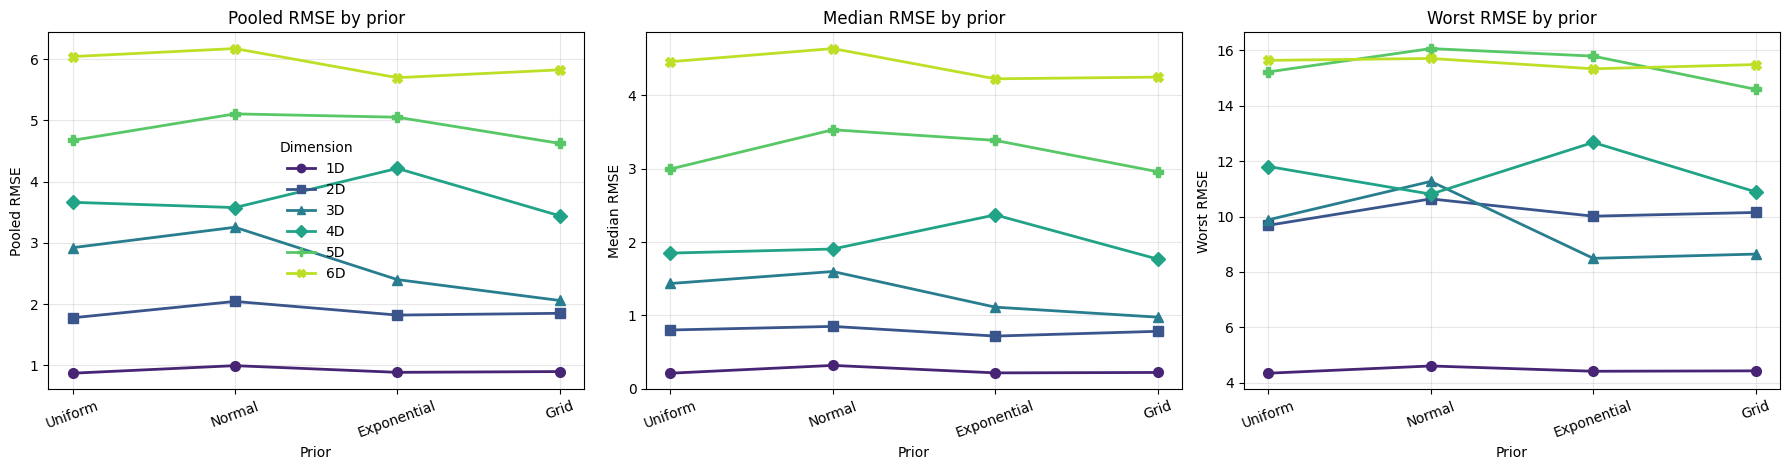

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
plot_metric_vs_prior(axes[0], runs_df, "pooled_rmse_log_r10", "Pooled RMSE by prior", "Pooled RMSE")
plot_metric_vs_prior(axes[1], runs_df, "median_rmse_log_r10", "Median RMSE by prior", "Median RMSE")
plot_metric_vs_prior(axes[2], runs_df, "worst_rmse_log_r10", "Worst RMSE by prior", "Worst RMSE")
legend_handles = build_dimension_legend_handles(ordered_dimensions(runs_df))
if legend_handles:
    axes[0].legend(handles=legend_handles, frameon=False, title="Dimension")
fig.tight_layout()
save_figure(fig, "accuracy_rmse_vs_prior")
plt.show()

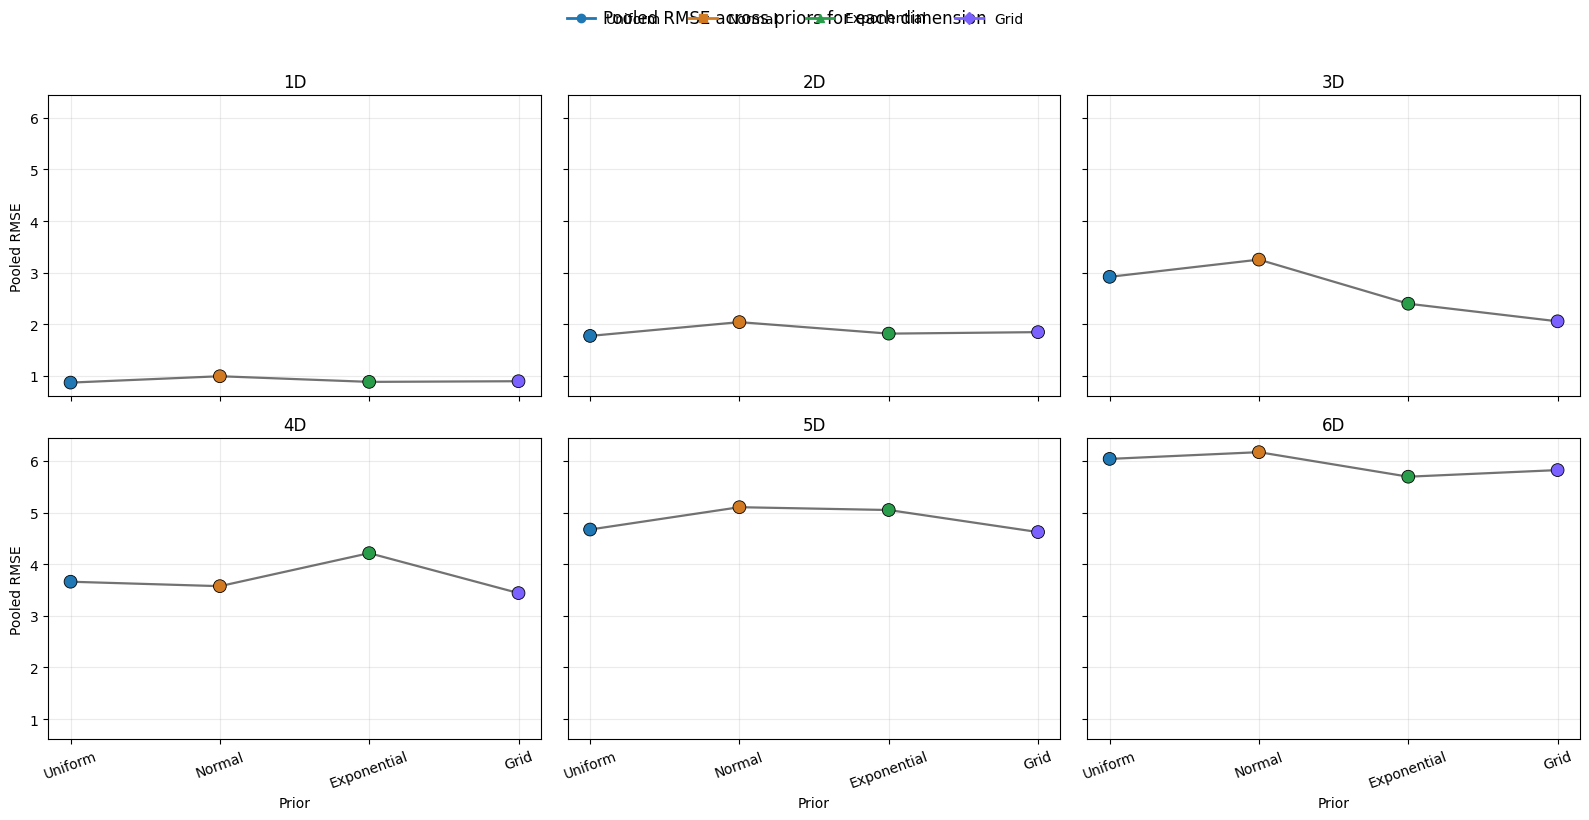

### Prior-focused interpretation
- **Grid** has the lowest mean pooled RMSE across the 1D-6D sweep (**3.115**).
- **Normal** has the largest average median ESS fraction (**0.047**), so it tends to preserve the strongest reweighting support.
- **Normal** is closest to nominal 68% coverage on average, with a mean absolute coverage gap of **0.191**.
- In the dimension-by-dimension win table, **Exponential** collects the most metric wins (**10** total).
- Relative to the uniform baseline, **Grid** yields the strongest mean pooled-RMSE improvement (**-0.208**).

In [6]:
fig = plot_metric_by_dimension_panels(
    runs_df,
    "pooled_rmse_log_r10",
    "Pooled RMSE across priors for each dimension",
    "Pooled RMSE",
    sharey=True,
)
save_figure(fig, "accuracy_pooled_rmse_by_dimension")
plt.show()

display(build_prior_observation_markdown(prior_summary_df, prior_win_count_df, delta_vs_uniform_df))

## Reweighting Quality

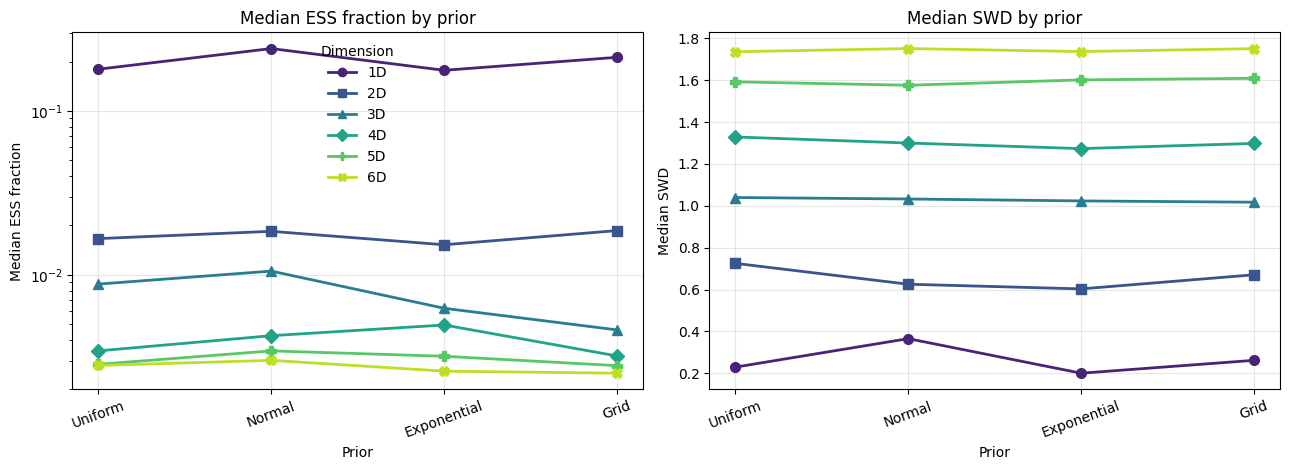

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
plot_metric_vs_prior(axes[0], runs_df, "median_ess_fraction", "Median ESS fraction by prior", "Median ESS fraction", logy=True)
plot_metric_vs_prior(axes[1], runs_df, "median_swd", "Median SWD by prior", "Median SWD")
legend_handles = build_dimension_legend_handles(ordered_dimensions(runs_df))
if legend_handles:
    axes[0].legend(handles=legend_handles, frameon=False, title="Dimension")
fig.tight_layout()
save_figure(fig, "reweighting_metrics_vs_prior")
plt.show()

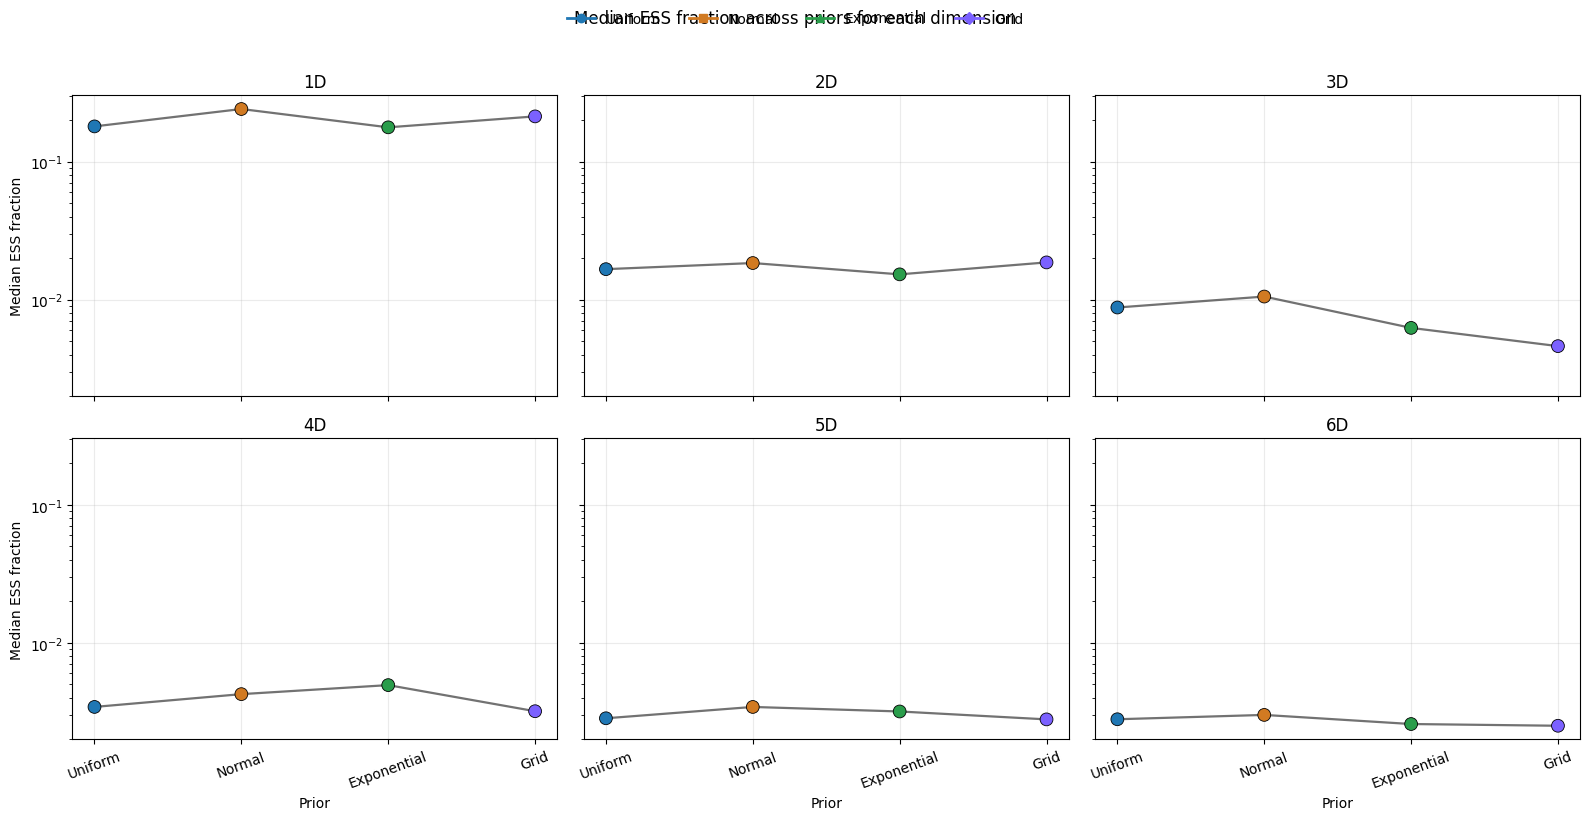

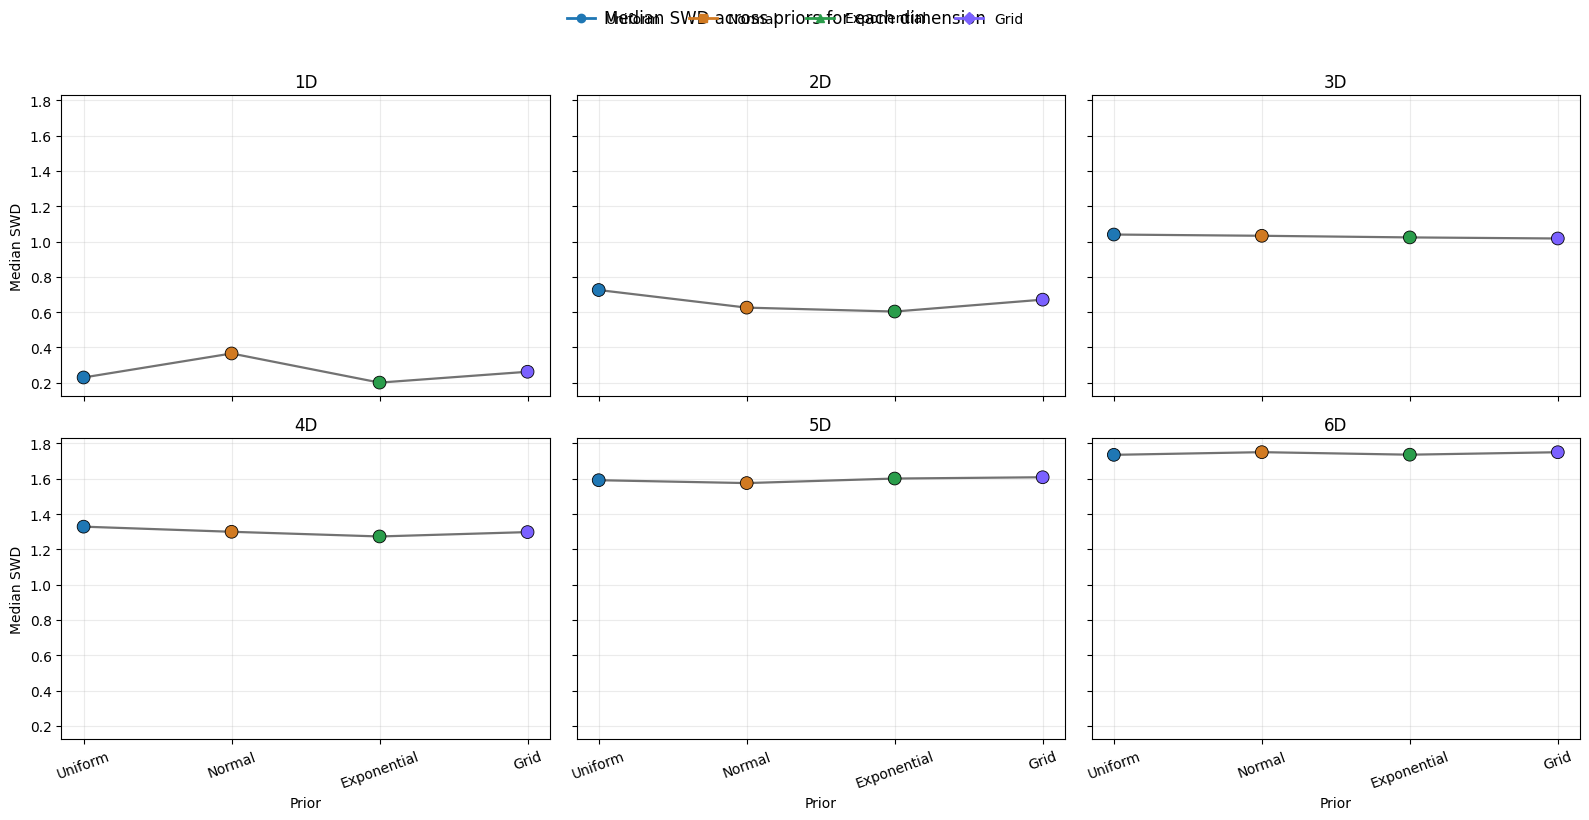

In [8]:
fig = plot_metric_by_dimension_panels(
    runs_df,
    "median_ess_fraction",
    "Median ESS fraction across priors for each dimension",
    "Median ESS fraction",
    logy=True,
    sharey=True,
)
save_figure(fig, "reweighting_ess_fraction_by_dimension")
plt.show()

fig = plot_metric_by_dimension_panels(
    runs_df,
    "median_swd",
    "Median SWD across priors for each dimension",
    "Median SWD",
    sharey=True,
)
save_figure(fig, "reweighting_swd_by_dimension")
plt.show()

## Calibration And Uncertainty

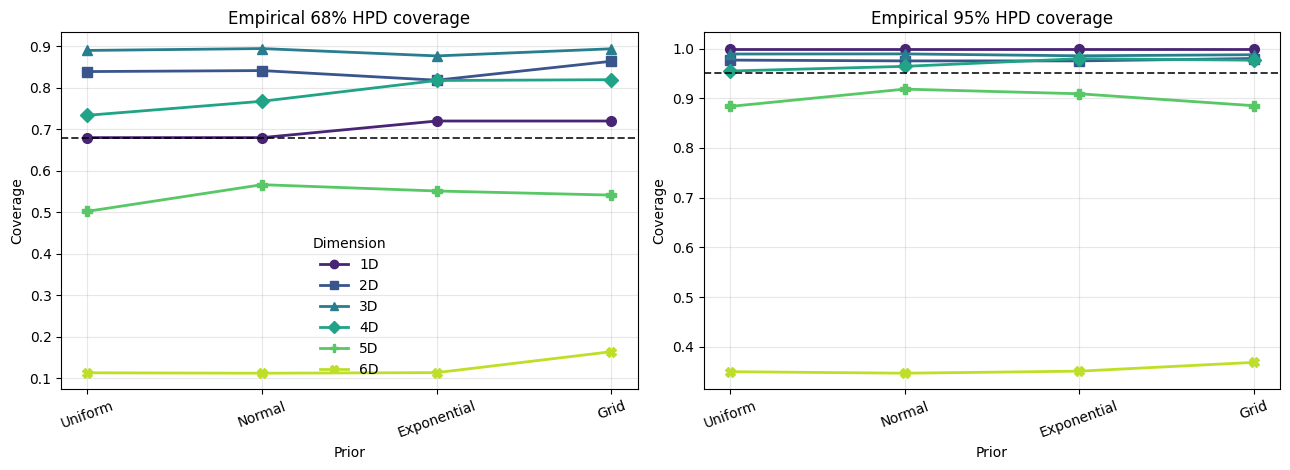

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
plot_metric_vs_prior(axes[0], runs_df, "coverage_68", "Empirical 68% HPD coverage", "Coverage", nominal=0.68)
plot_metric_vs_prior(axes[1], runs_df, "coverage_95", "Empirical 95% HPD coverage", "Coverage", nominal=0.95)
legend_handles = build_dimension_legend_handles(ordered_dimensions(runs_df))
if legend_handles:
    axes[0].legend(handles=legend_handles, frameon=False, title="Dimension")
fig.tight_layout()
save_figure(fig, "calibration_coverage_vs_prior")
plt.show()

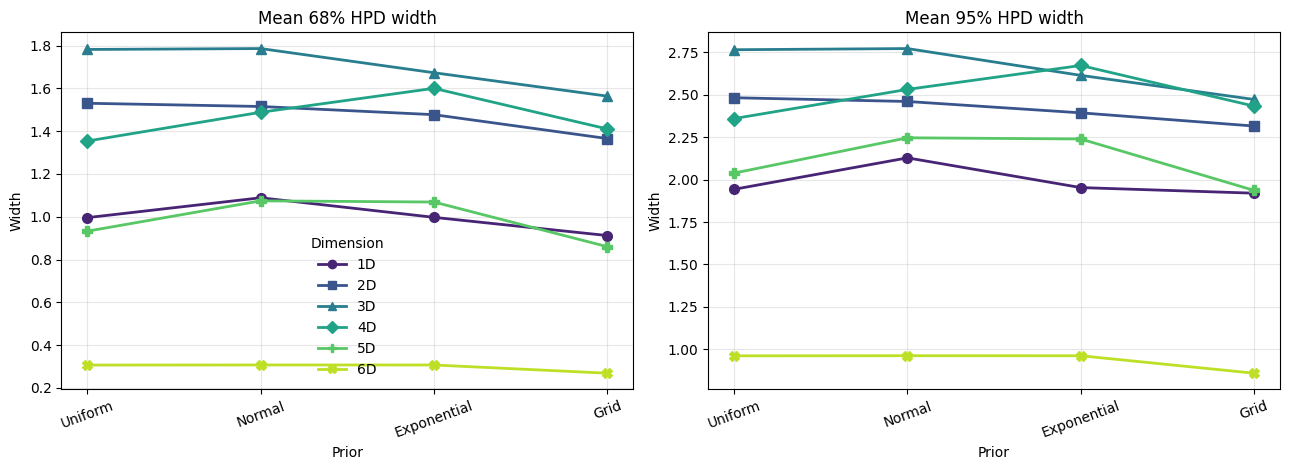

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
plot_metric_vs_prior(axes[0], runs_df, "mean_interval_width_68", "Mean 68% HPD width", "Width")
plot_metric_vs_prior(axes[1], runs_df, "mean_interval_width_95", "Mean 95% HPD width", "Width")
legend_handles = build_dimension_legend_handles(ordered_dimensions(runs_df))
if legend_handles:
    axes[0].legend(handles=legend_handles, frameon=False, title="Dimension")
fig.tight_layout()
save_figure(fig, "calibration_interval_width_vs_prior")
plt.show()

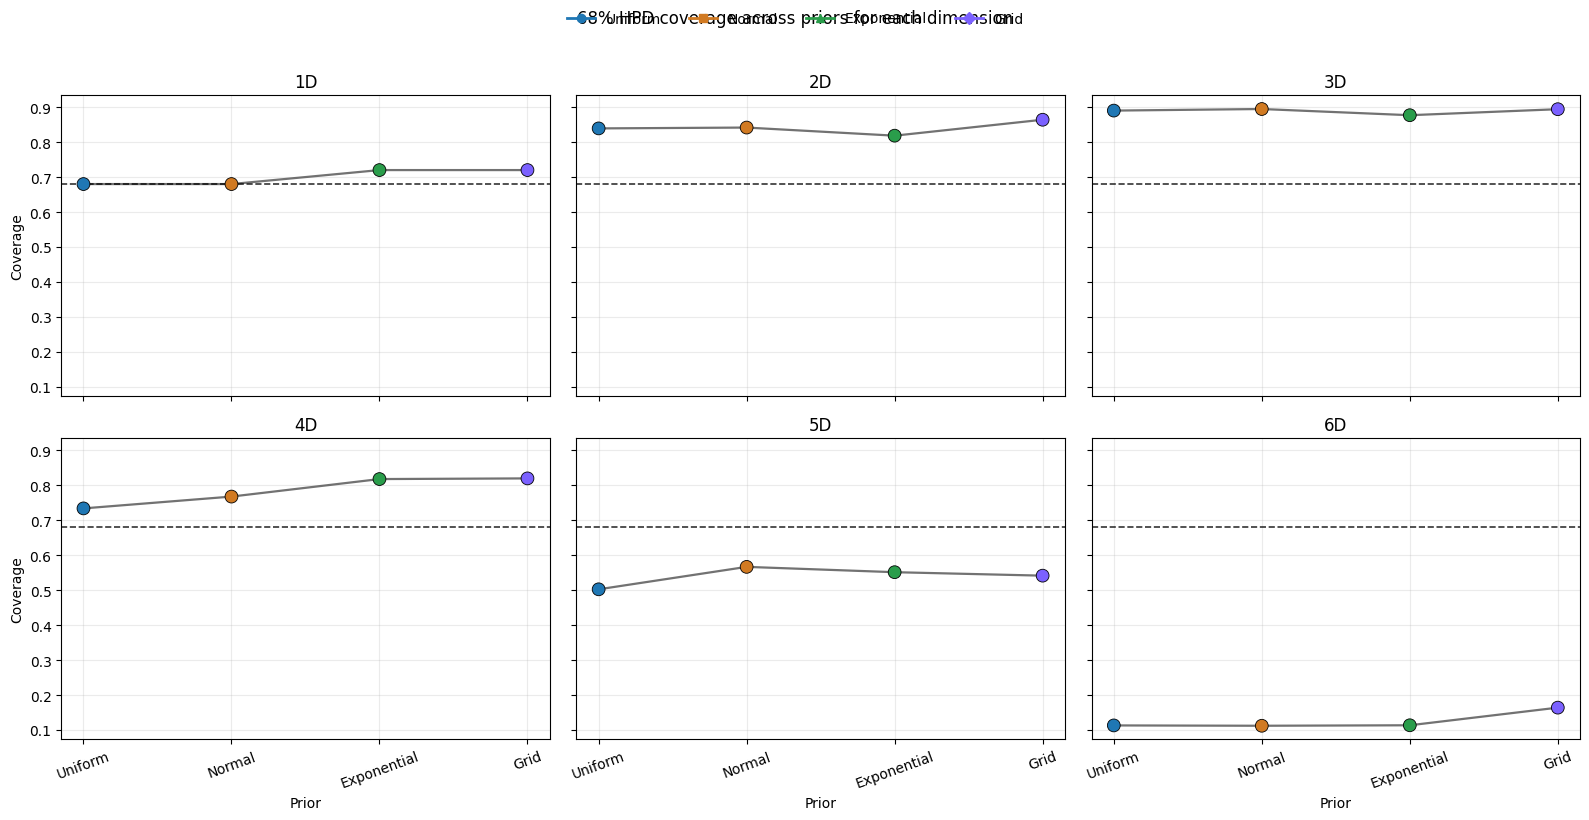

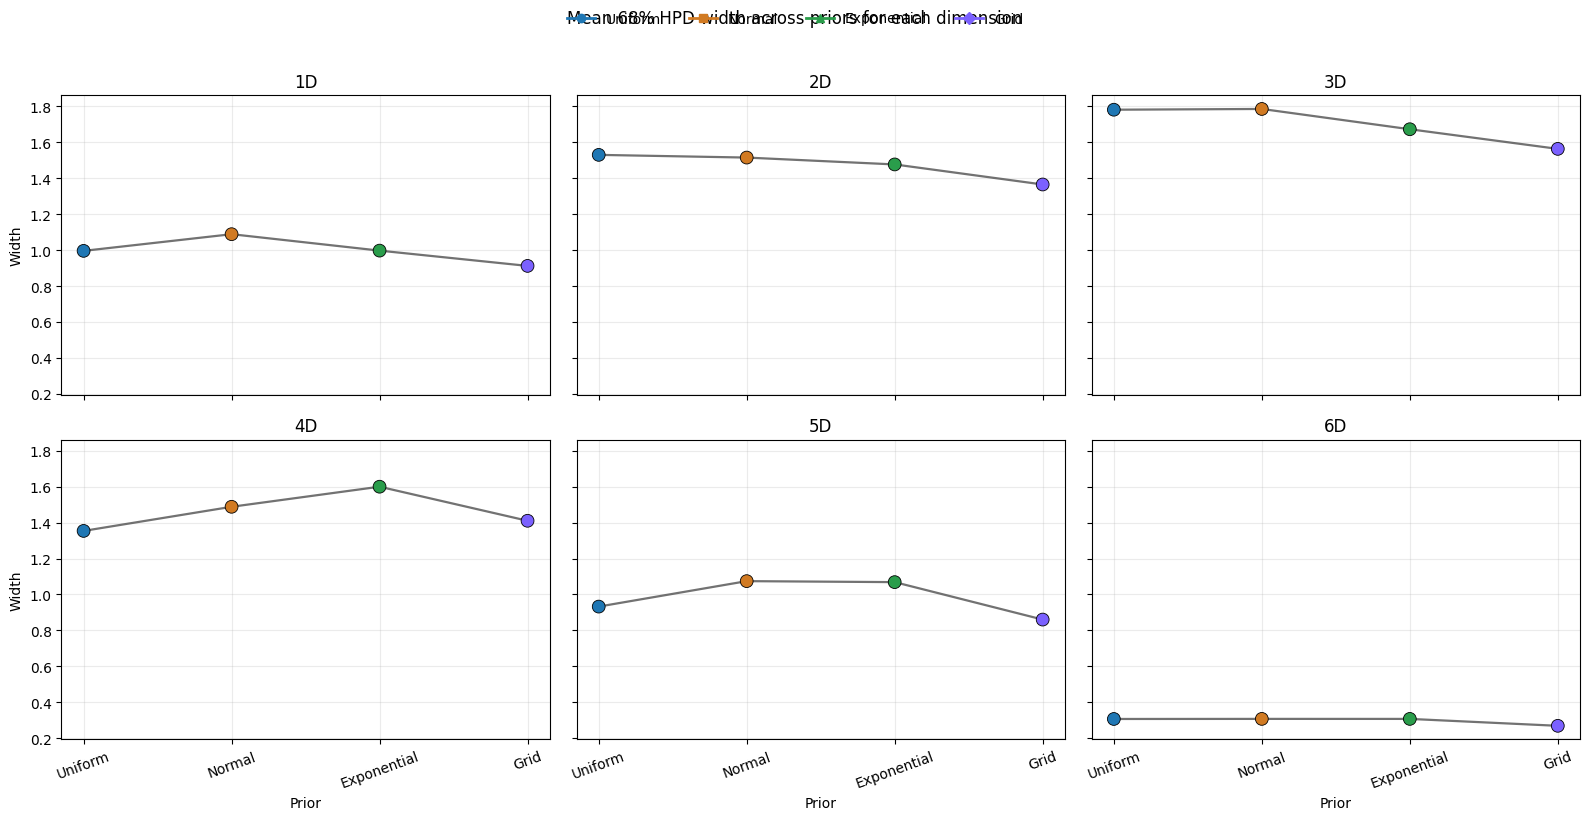

In [11]:
fig = plot_metric_by_dimension_panels(
    runs_df,
    "coverage_68",
    "68% HPD coverage across priors for each dimension",
    "Coverage",
    nominal=0.68,
    sharey=True,
)
save_figure(fig, "calibration_coverage_68_by_dimension")
plt.show()

fig = plot_metric_by_dimension_panels(
    runs_df,
    "mean_interval_width_68",
    "Mean 68% HPD width across priors for each dimension",
    "Width",
    sharey=True,
)
save_figure(fig, "calibration_interval_width_68_by_dimension")
plt.show()

## Distance-Driven Difficulty

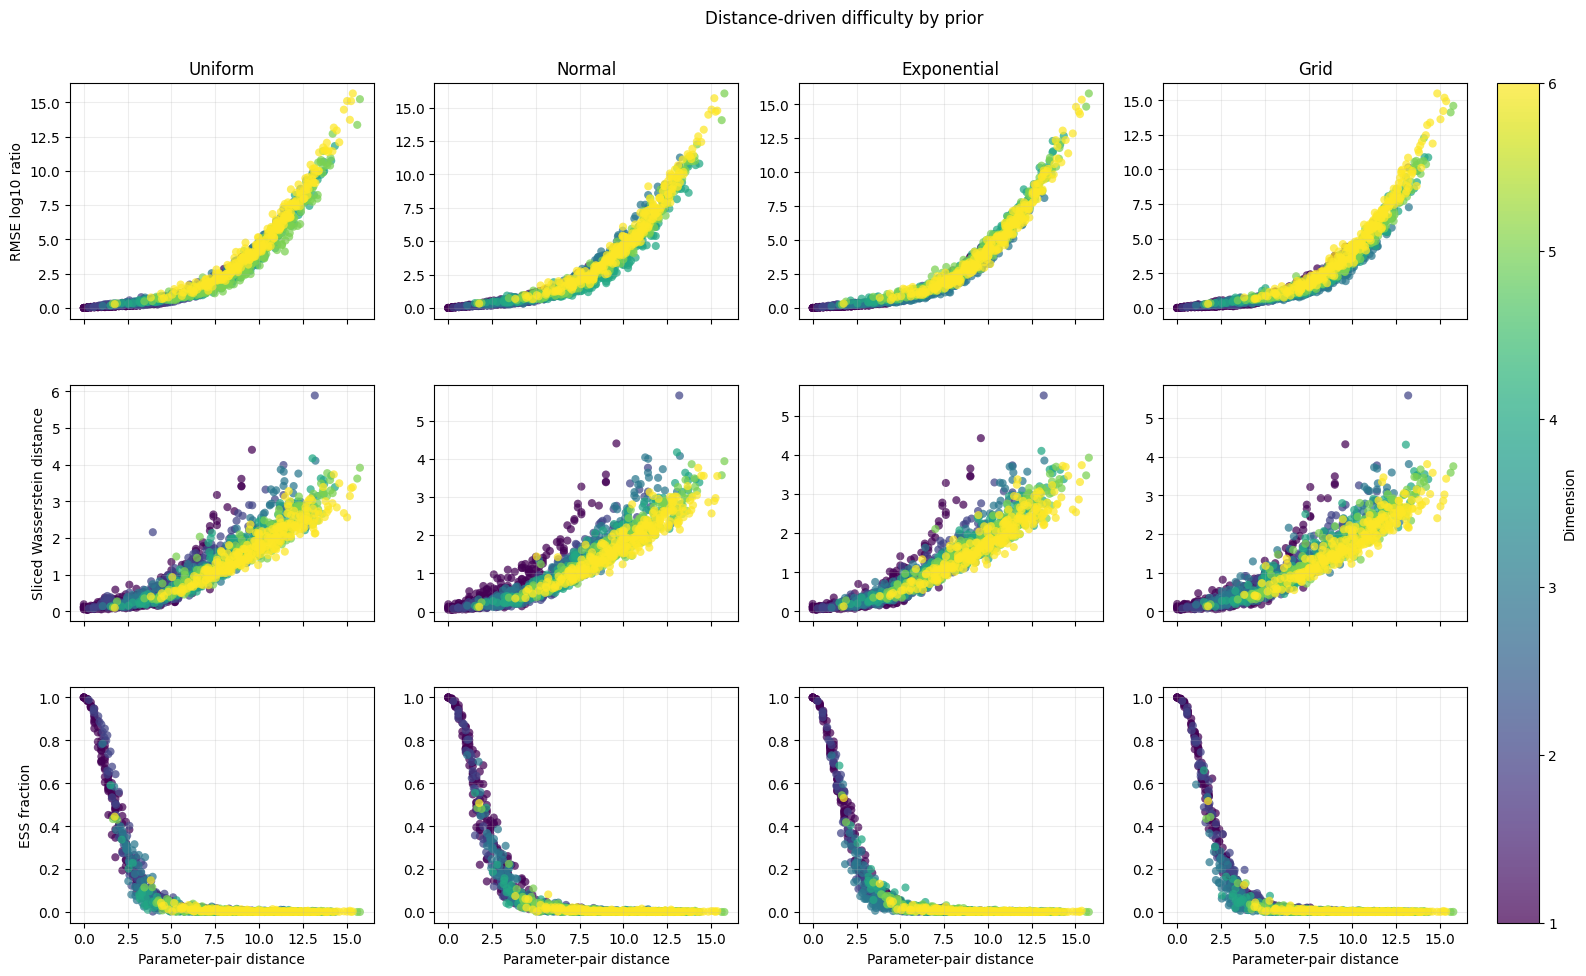

In [12]:
fig = plot_prior_facet_metric_grid(pairs_df)
fig.suptitle("Distance-driven difficulty by prior", y=0.99)
save_figure(fig, "difficulty_distance_vs_metrics_by_prior")
plt.show()

In [13]:
display(correlation_summary_df)

,dimension,prior,spearman_rmse_vs_distance,spearman_swd_vs_distance,spearman_ess_fraction_vs_distance
0,1,exponential,0.975,0.878,-0.990
1,1,grid,0.929,0.857,-0.990
2,1,normal,0.970,0.866,-0.979
3,1,uniform,0.963,0.839,-0.988
4,2,exponential,0.987,0.961,-0.936
5,2,grid,0.985,0.948,-0.928
6,2,normal,0.990,0.961,-0.936
7,2,uniform,0.970,0.922,-0.918
8,3,exponential,0.988,0.962,-0.848
9,3,grid,0.971,0.938,-0.805


## Position-Dependent Behavior

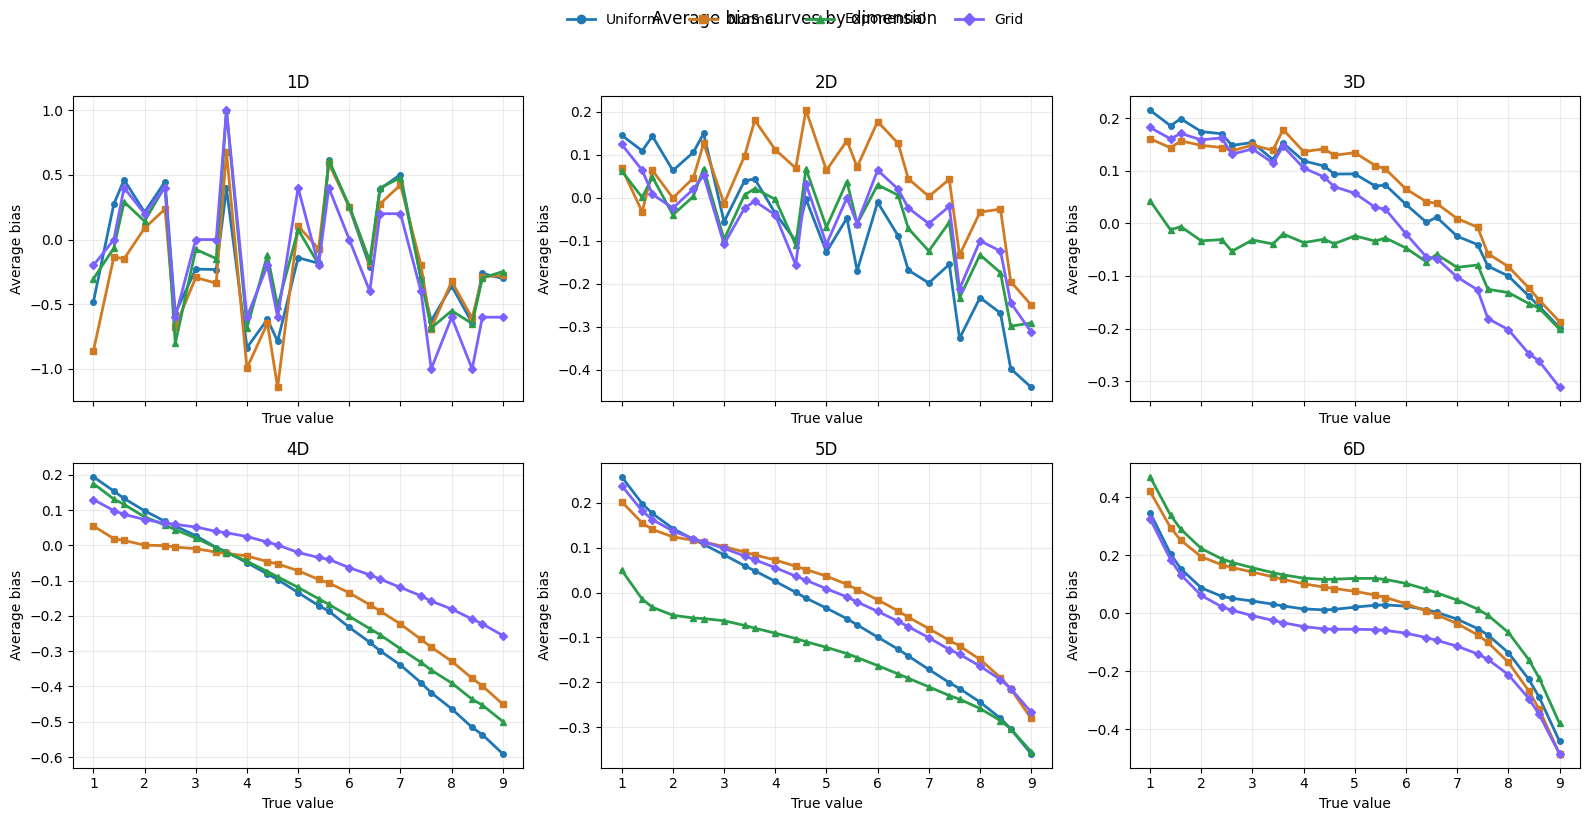

In [14]:
fig = plot_curve_by_dimension(curves_df, "avg_bias", "Average bias", "Average bias curves by dimension")
save_figure(fig, "position_avg_bias_by_dimension")
plt.show()

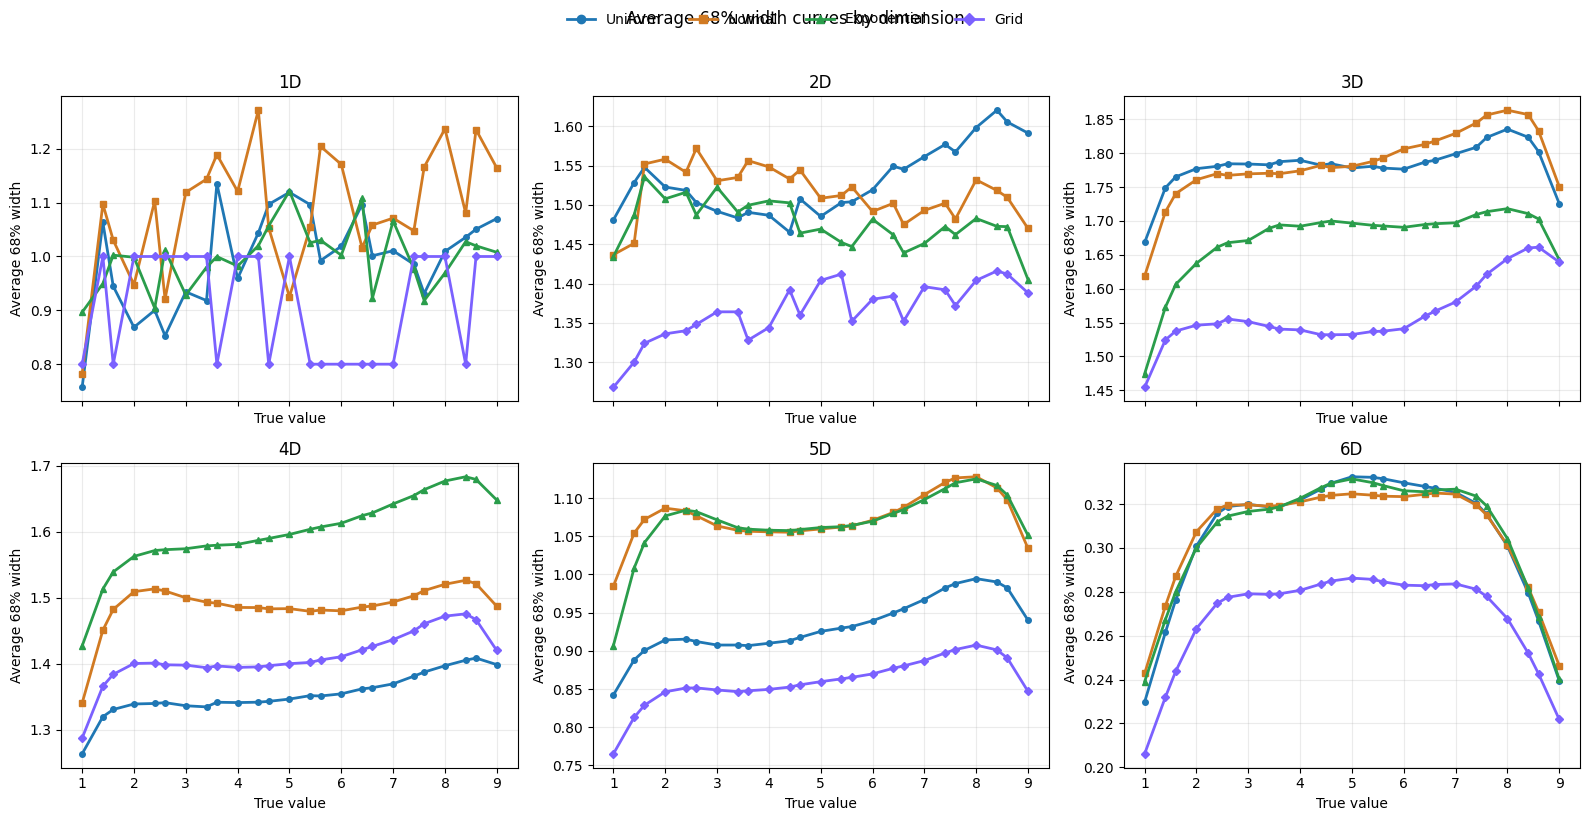

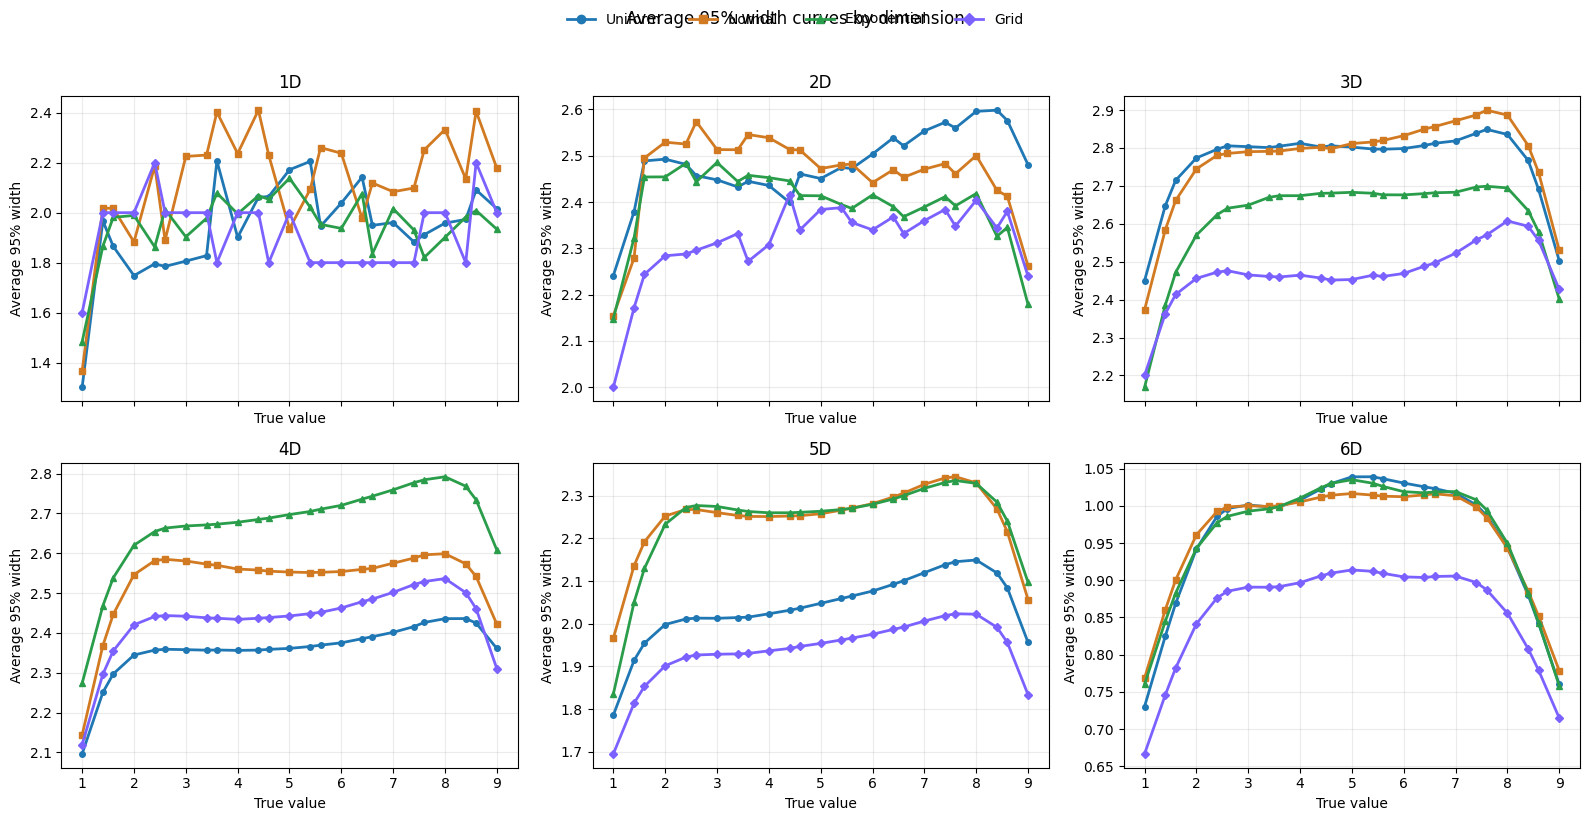

In [15]:
fig = plot_curve_by_dimension(curves_df, "avg_width_68", "Average 68% width", "Average 68% width curves by dimension")
save_figure(fig, "position_avg_width_68_by_dimension")
plt.show()

fig = plot_curve_by_dimension(curves_df, "avg_width_95", "Average 95% width", "Average 95% width curves by dimension")
save_figure(fig, "position_avg_width_95_by_dimension")
plt.show()

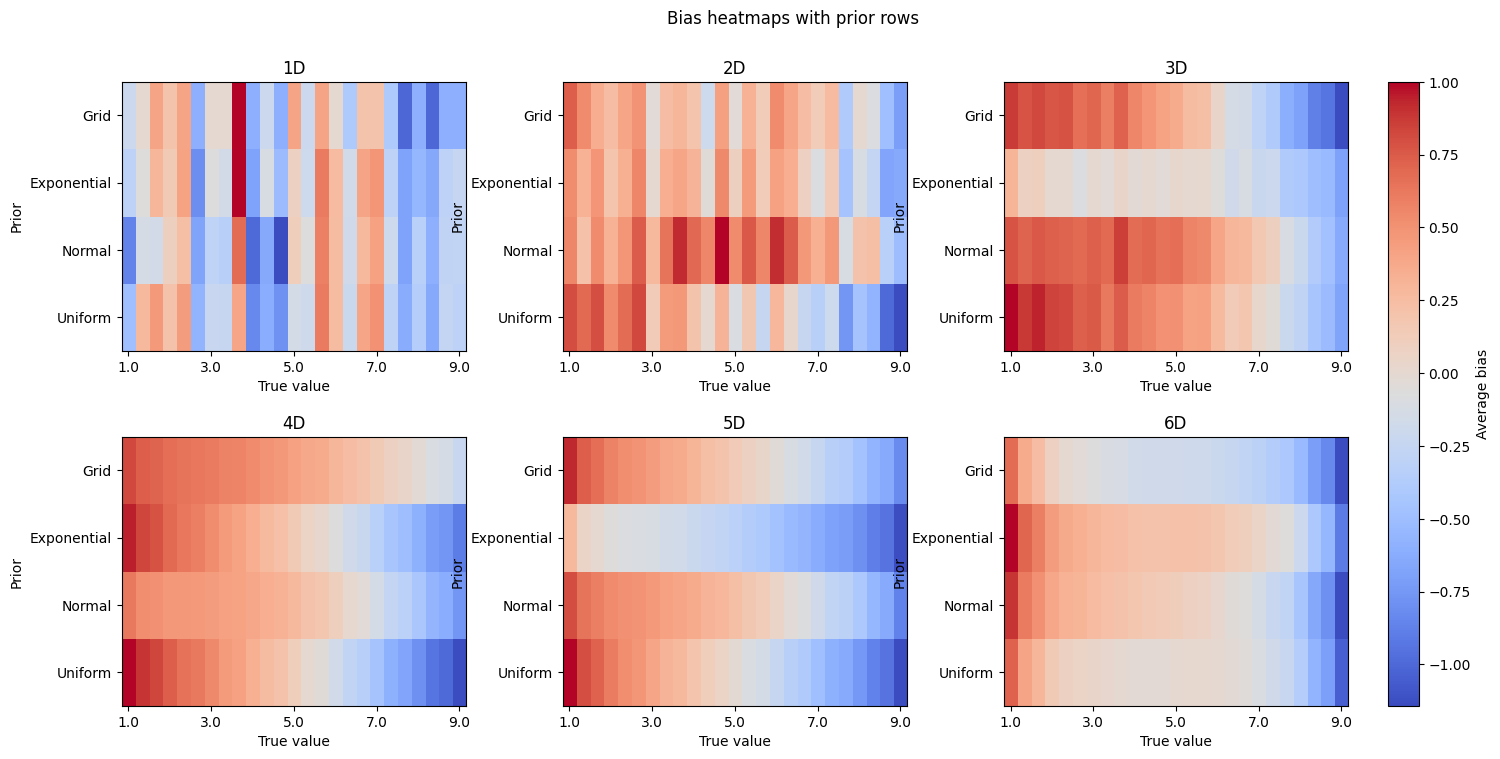

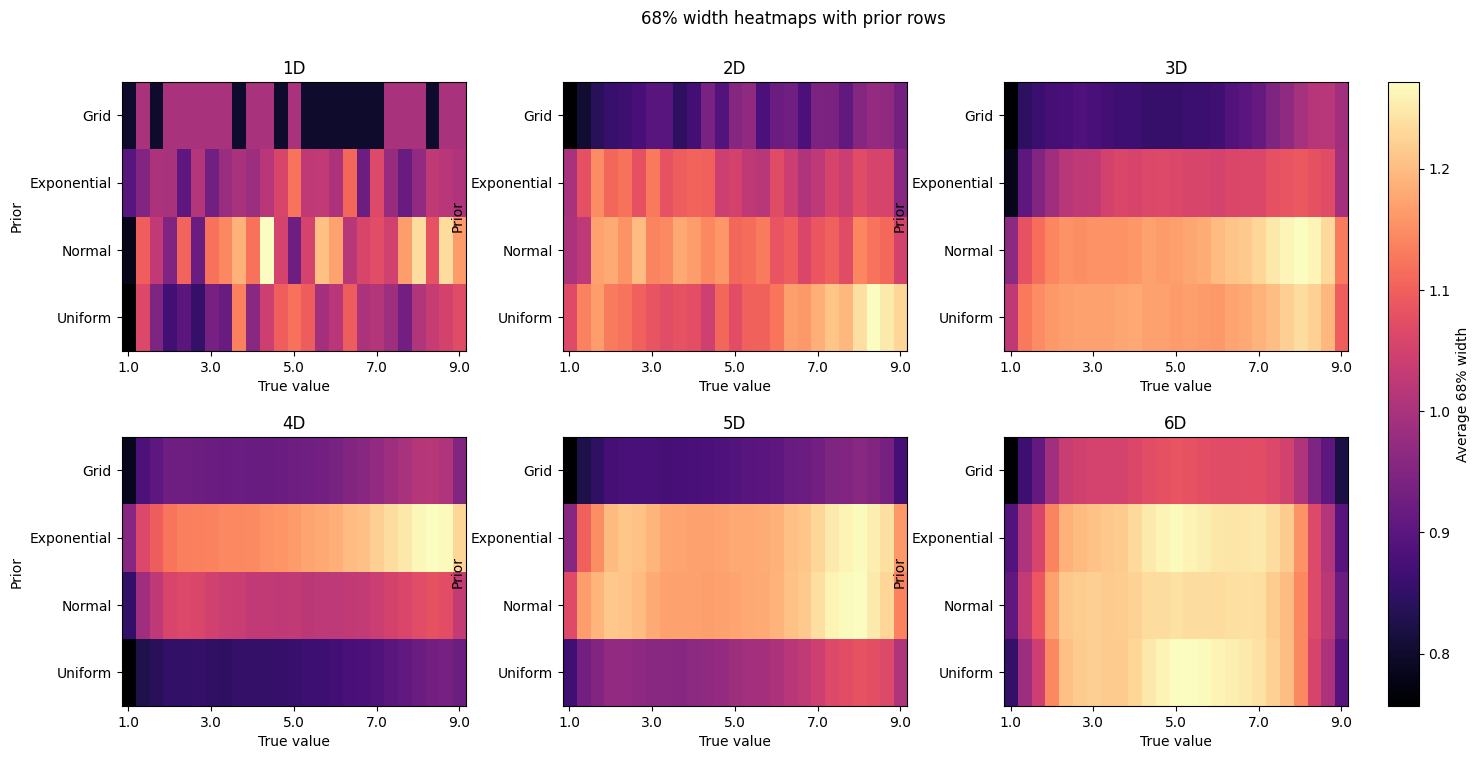

In [16]:
fig = plot_curve_heatmaps_by_dimension(curves_df, "avg_bias", "Average bias", cmap="coolwarm")
fig.suptitle("Bias heatmaps with prior rows", y=0.99)
save_figure(fig, "position_avg_bias_heatmap_by_dimension")
plt.show()

fig = plot_curve_heatmaps_by_dimension(curves_df, "avg_width_68", "Average 68% width", cmap="magma")
fig.suptitle("68% width heatmaps with prior rows", y=0.99)
save_figure(fig, "position_avg_width_68_heatmap_by_dimension")
plt.show()

## Raw Deep Dive (Optional)

In [17]:
if not LOAD_RAW:
    display(
        Markdown(
            f"Set `LOAD_RAW = True` to enable the compact-store deep dive. "
            f"The loader samples each config/prior combination down to at most **{RAW_MAX_POINTS_PER_CONFIG:,}** posterior settings so the full 1D-6D sweep stays usable."
        )
    )
elif raw_metadata_df.empty:
    display(Markdown("Raw loading was enabled, but no compact-store artifacts were available for the requested sweep."))
else:
    display(raw_metadata_df)

,config_id,dimension,prior,n_total_points,n_loaded_points,sampled
0,config_018,1,exponential,25,25,False
1,config_018,1,grid,25,25,False
2,config_018,1,normal,25,25,False
3,config_018,1,uniform,25,25,False
4,config_013,2,exponential,625,256,True
5,config_013,2,grid,625,256,True
6,config_013,2,normal,625,256,True
7,config_013,2,uniform,625,256,True
8,config_012,3,exponential,15625,256,True
9,config_012,3,grid,15625,256,True


/tmp/ipykernel_3662819/2708715468.py:465: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(
/tmp/ipykernel_3662819/2708715468.py:465: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(
/tmp/ipykernel_3662819/2708715468.py:465: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(
/tmp/ipykernel_3662819/2708715468.py:465: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(
/tmp/ipykernel_3662819/2708715468.py:465: MatplotlibDeprecat

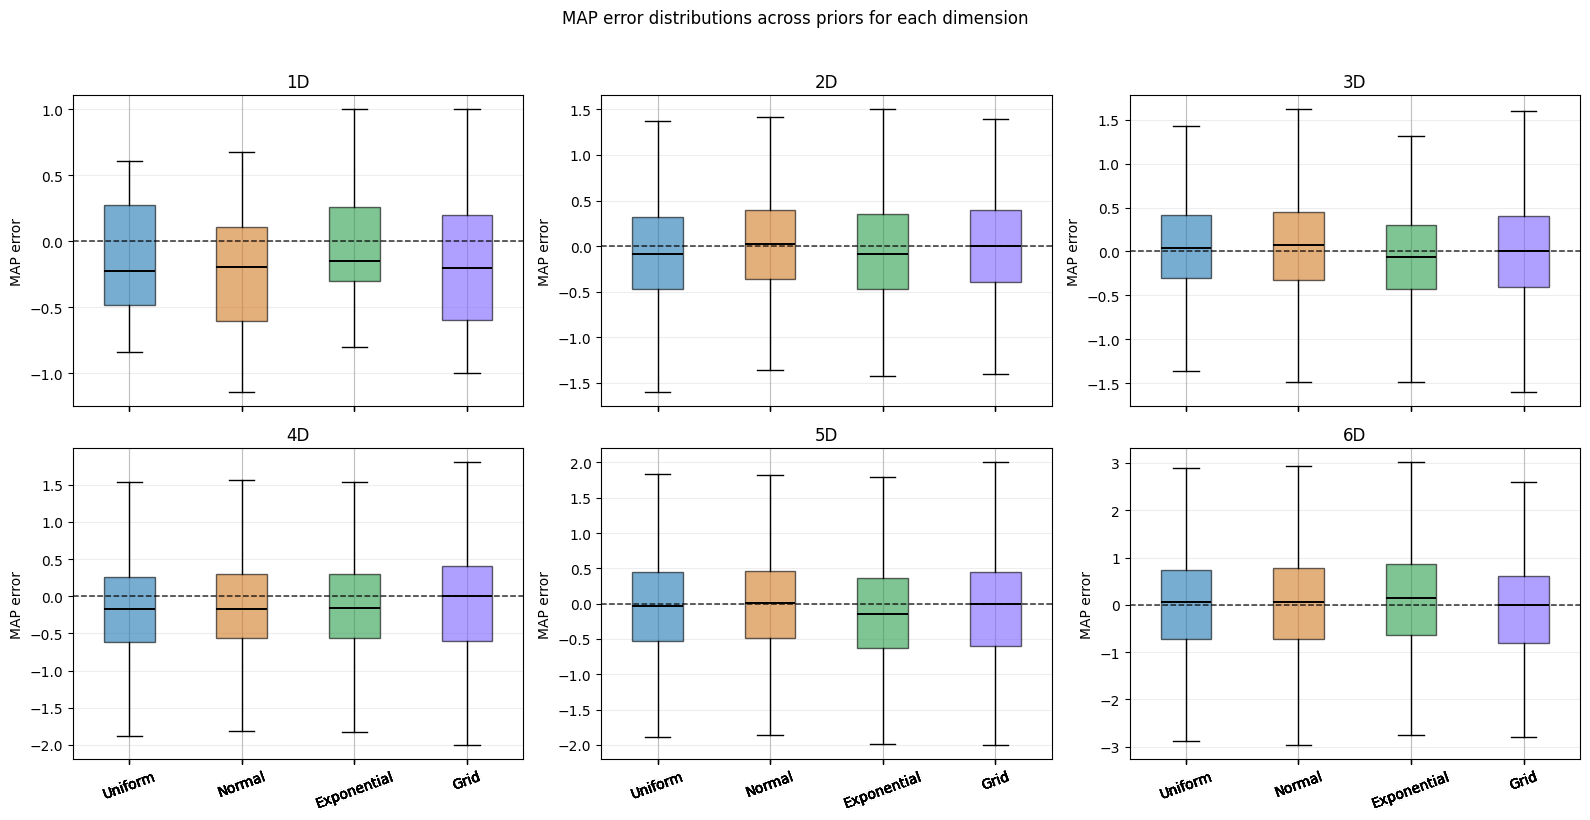

/tmp/ipykernel_3662819/2708715468.py:465: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(
/tmp/ipykernel_3662819/2708715468.py:465: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(
/tmp/ipykernel_3662819/2708715468.py:465: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(
/tmp/ipykernel_3662819/2708715468.py:465: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(
/tmp/ipykernel_3662819/2708715468.py:465: MatplotlibDeprecat

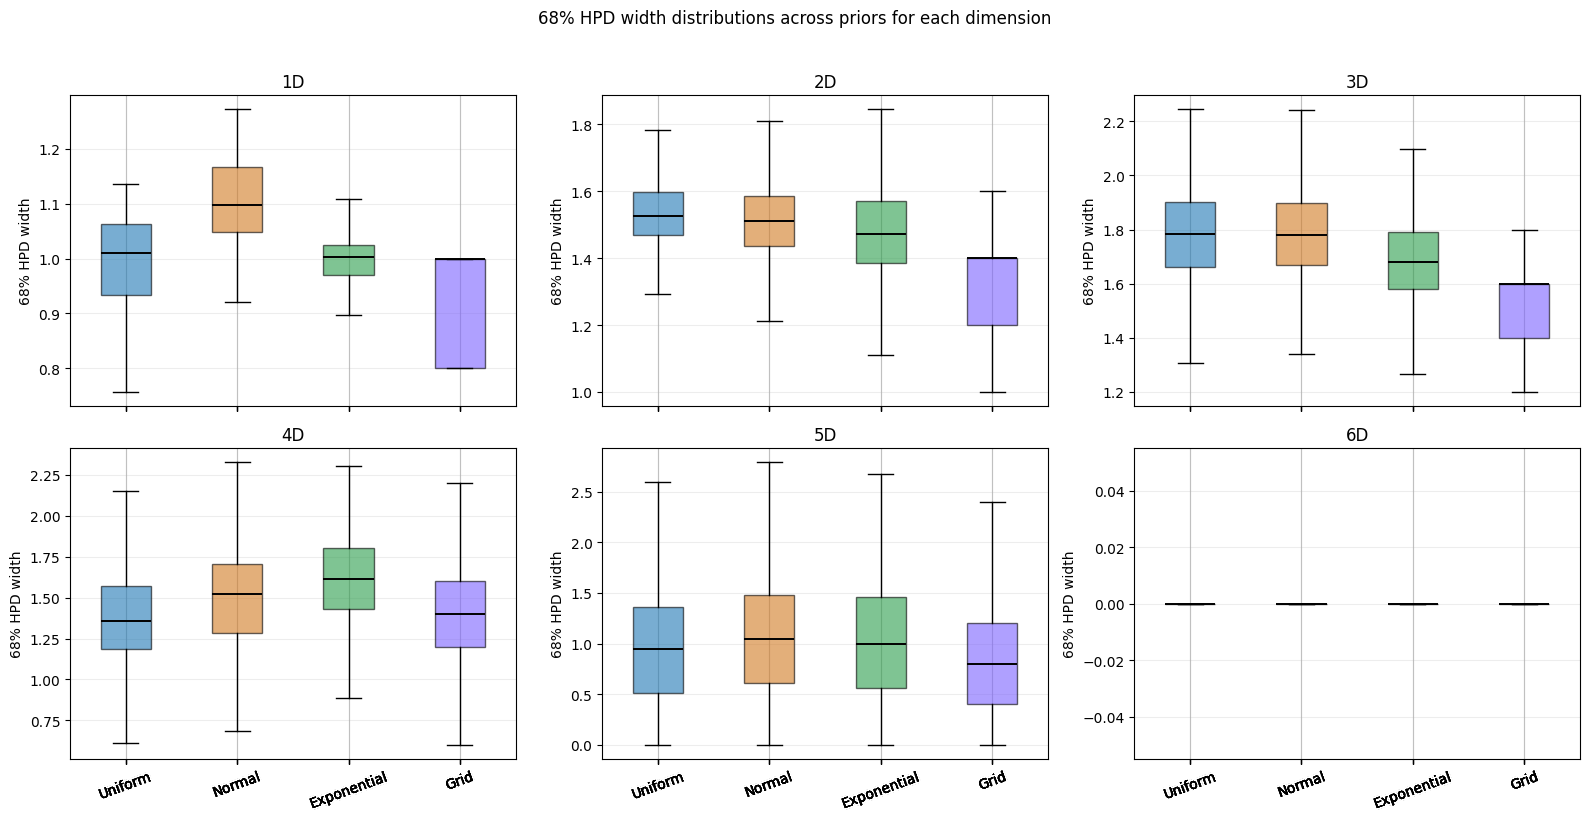

In [18]:
if LOAD_RAW and not raw_metadata_df.empty:
    interval_68_df = raw_intervals_df.loc[raw_intervals_df["interval_level"].astype(str) == "68"].copy()

    fig = plot_raw_boxplots_by_dimension(
        raw_map_df,
        "map_error",
        "MAP error",
        "MAP error distributions across priors for each dimension",
        add_zero_line=True,
    )
    save_figure(fig, "raw_map_error_boxplots_by_dimension")
    plt.show()

    fig = plot_raw_boxplots_by_dimension(
        interval_68_df,
        "width",
        "68% HPD width",
        "68% HPD width distributions across priors for each dimension",
    )
    save_figure(fig, "raw_width_68_boxplots_by_dimension")
    plt.show()